<font size="5.8">Summary</font>  

This work demonstrates how to build and compare three common multi-agent architectures in **LangGraph**: **Any-to-Any Networks**, **Supervisor Multi-Agents**, and **Supervisor Tool-Calling Multi-Agents**. It begins by explaining the strengths, limitations, and ideal use cases of each architecture. The notebook then creates specialized agent tools and shows how agents communicate, delegate tasks, and coordinate workflows. Practical LangGraph implementations are provided for each architecture, including routing logic and agent orchestration. It also highlights differences between decentralized and centralized agent coordination, helping users understand when each design pattern is most effective. Overall, the notebook serves as a hands-on guide for designing scalable multi-agent AI systems using LangGraph.

<div style="display: flex; justify-content: center; gap: 20px;"> <img src="https://raw.githubusercontent.com/mehdirezvandehy/multi-agent-systems-with-langGraph/main/assets/any-to-any.gif" width="500"> <img src="https://raw.githubusercontent.com/mehdirezvandehy/multi-agent-systems-with-langGraph/main/assets/supervisor.gif" width="500"> </div>

Before running the project, create a `.env` file in the root directory and add the required API keys:

```bash
OPENAI_API_KEY=your_openai_api_key_here
SERP_API_KEY=your_serpapi_key_here
```

* `OPENAI_API_KEY` → required for OpenAI-based LLM / GenAI functionality
* `SERP_API_KEY` → required for Google Search (SerpAPI) tool integration
  
These environment variables are loaded automatically in the code:


The notebook `multi_agent_orchestration.ipynb` with educational simple examples, along with modular Python implementations designed for production use, is available in this repository:
https://github.com/MehdiRezvandehy/multi_agent_orchestration_systems_with_langGraph.git


The modular implementation is organized as follows:

* **Agents** (`agents.py`)
* **Tools** (`tools.py`)
* **Architecture configurations** (`any_to_any_network.py`, `supervisor_network.py`, `supervisor_tool_calling.py`)

Both the notebook and Python implementations can be executed either in a virtual environment or using Docker Compose. However, Docker Compose is recommended because it provides a consistent, reproducible, and dependency-free environment across different machines.




For detailed instructions on how to run the notebook and Python implementations, please refer to the `README.md` in the repository:
https://github.com/MehdiRezvandehy/multi_agent_orchestration_systems_with_langGraph


<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Multi-agent-Systems-(Architectures)" data-toc-modified-id="Multi-agent-Systems-(Architectures)-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Multi-agent Systems (Architectures)</a></span></li><li><span><a href="#Create-Agent-Tools" data-toc-modified-id="Create-Agent-Tools-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Create Agent Tools</a></span></li><li><span><a href="#Any-to-Any-Multi-Agent-Networks" data-toc-modified-id="Any-to-Any-Multi-Agent-Networks-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Any-to-Any Multi-Agent Networks</a></span></li><li><span><a href="#Supervisor-Multi-Agents" data-toc-modified-id="Supervisor-Multi-Agents-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Supervisor Multi-Agents</a></span></li><li><span><a href="#Supervisor-Tool-Calling-Multi-Agents" data-toc-modified-id="Supervisor-Tool-Calling-Multi-Agents-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Supervisor Tool Calling Multi-Agents</a></span></li></ul></div>

# Multi-agent Systems (Architectures)

Sometimes, a single agent is not enough. A single agent typically works sequentially, executing tools one after another. As the number of tools available to an agent increases, the agent can become confused about which tool to use. This can result from overly long prompts, excessive guardrails, too many tool calls, detailed tool descriptions, or even tool hallucinations.

One way to address this problem is through a multi-agent system, where multiple agents work together collaboratively. There are many different ways to design and architect multi-agent systems.

The concept of an agent itself remains the same as a standard ReAct agent: it includes prompts, context, instructions, and tools. In other words, an agent is simply a combination of prompts, tools, and reasoning capabilities—nothing fundamentally different.

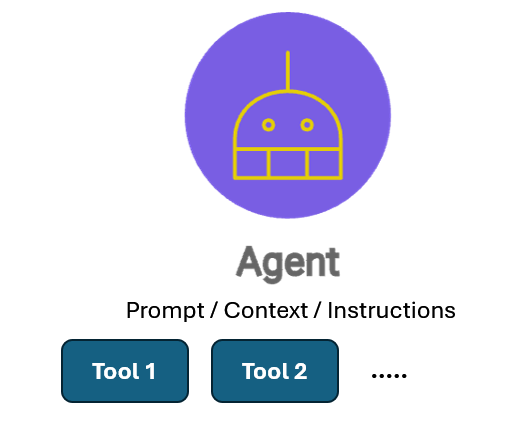

There are three common ways of constructing multi-agent systems:

1. **Any-to-any Networks**

   It has the simplest and most flexible multi-agent design. In this setup, every agent has full autonomy to pass the entire conversation history to any other agent at any time. This approach is straightforward and somewhat naïve: each agent can see everything that has happened so far and can decide independently who should handle the next step. For example, a coding agent (Python) might pass the full conversation to a math agent, or a web-retrieval agent, depending on the task.
   
   The main advantage is simplicity. You don’t need to worry about managing or filtering context—every agent always has full visibility into the conversation. However, this comes with important trade-offs.
   
   First, each agent now carries additional responsibility. Beyond performing its core task, it must also decide when and where to route the conversation next. This increases system complexity and can lead to poor decisions if agents are not well-designed for coordination.
   
   Second, there is a cost and efficiency concern. Some agents are intentionally lightweight—designed to be fast and inexpensive for simple tasks. Expecting them to also handle routing decisions (often implemented via tool-calling) adds overhead and can negate their efficiency benefits.
   
   While this architecture is easy to implement, it is often not the most efficient or scalable approach. More structured designs can reduce cost, improve reliability, and better separate responsibilities across agents.

<div style="display: flex; justify-content: center; gap: 60px;">
  <img src="https://raw.githubusercontent.com/mehdirezvandehy/multi-agent-systems-with-langGraph/main/assets/any-to-any.gif"
       width="480">

2. **Supervisor Networks**

   Supervisor networks are a type of multi-agent architecture in which a central supervisor agent manages and coordinates all interactions between sub-agents. The supervisor is responsible for task delegation, routing decisions, and controlling the overall workflow, while sub-agents focus only on executing their assigned tasks.
   
   A key caveat of **supervisor networks** is that they are not always the optimal architectural choice. However, in practice, when people build multi-agent systems, a large portion of them—arguably around 70%—end up implementing some form of supervised architecture, even if unintentionally.
   
   In a supervisor network, a central supervisor agent orchestrates the flow of communication between agents. Messages may still pass between agents, but the critical constraint is that only the supervisor controls these transitions. In other words, the supervisor is responsible for deciding which agent should handle each stage of the task.
   
   In some implementations, conversation history may be truncated or summarized to keep interactions concise. However, in a pure supervisor architecture, the workflow follows a strict pattern: the supervisor assigns a task to a sub-agent, the sub-agent performs the assigned work, and **then control is always returned to the supervisor**.
   
   Sub-agents do not make routing or coordination decisions. Their responsibility is limited to executing the task they receive. Typically, each sub-agent is provided with the relevant context along with a clear instruction from the supervisor. After completing the task, the sub-agent reports the results back to the supervisor, which then determines the next step in the workflow.
   
   As a result, all coordination, routing, and high-level decision-making remain centralized within the supervisor agent.


<div style="display: flex; justify-content: center; gap: 60px;">
  <img src="https://raw.githubusercontent.com/mehdirezvandehy/multi-agent-systems-with-langGraph/main/assets/supervisor.gif"
       width="480">

3. **Supervisor Tool-Calling**

   A hybrid variation of the supervisor model is **supervisor tool-calling**. It still follows the same overall structure—there is a supervisor, sub-agents, and task delegation—but the interaction pattern is different.
   
   Instead of passing the full conversation to sub-agents, the supervisor treats them as tools. Rather than saying, “Here is the entire conversation, handle the next step,” the supervisor keeps control of the dialogue with the user and only engages sub-agents when needed. In those moments, it communicates with them privately, providing just the specific context required to complete a task.
   
   In this setup, the supervisor acts as a **strict gatekeeper**. **Sub-agents do not see the full conversation—only the relevant pieces necessary for their task**. This leads to significant efficiency gains: less context to process means lower cost, faster responses, and more focused execution. In many ways, sub-agents behave like specialized “ReAct-style” tools that perform well-defined actions.
   
   However, this design also introduces a trade-off. The system now relies heavily on the supervisor’s ability to provide the right context at the right time. Even if powered by a strong reasoning LLM, the **supervisor can still omit important details**. Sub-agents typically proceed with whatever context they are given and are not always designed to question missing information. To mitigate this, you can equip sub-agents with a mechanism (e.g., a tool or protocol) to request additional context when needed.


<div style="display: flex; justify-content: center; gap: 60px;">
  <img src="https://raw.githubusercontent.com/mehdirezvandehy/multi-agent-systems-with-langGraph/main/assets/supervisor_tool_calling.gif"
       width="480">

The key question is when to use each of these architectures.

- A **centralized (supervisor-based) model** works best for structured, enterprise workflows—such as SDR (Sales Development Representative) pipelines—where tasks are predictable, sequential, and need tight control.

- A **decentralized (any-to-any) model** is better suited for creative or exploratory scenarios, like collaborative research. In these cases, agents benefit from autonomy and flexibility—there’s no strict order, and they can decide how to approach the problem. For example, asking an agent to “**go figure out the best way to solve this**” fits well here, whereas a task like drafting an email is more straightforward and doesn’t require that level of freedom.


- The **supervisor-as-tool-caller** architecture sits in the middle, balancing control and flexibility by centralizing coordination while keeping sub-agents focused and efficient.


Here is LangGraph implementation for the three constructing multi-agent systems:

In [1]:
import os

# Load environment variables (e.g., OPENAI_API_KEY)
from dotenv import load_dotenv
load_dotenv(override=True)

# Load API keys
# Provide your credentials and API keys in a `.env` file to authenticate services
#(OpenAI API key, email credentials, Tavily API key).
os.environ['OPENAI_API_KEY'] = os.environ.get("OPENAI_API_KEY")
os.environ["SERP_API_KEY"] = os.environ.get("SERP_API_KEY")

**In cyclic “any-to-any” graphs, LangGraph will NOT auto-stop just because an answer exists.**

# Create Agent Tools 

In [2]:
import warnings
warnings.filterwarnings('ignore')
from typing import Literal
from langchain_openai import ChatOpenAI
from langgraph.types import Command
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from pydantic import BaseModel
from langgraph.prebuilt import InjectedState, create_react_agent

In [3]:
from rich.console import Console
from rich.markdown import Markdown
import re

console = Console()

def format_workflow_activity(activity_log):
    """Generate formatted workflow activity text."""

    output = []

    for worker_id, worker_data in activity_log.items():

        output.append(f"\n# 🤖 Agent: {worker_id}\n")

        if "messages" not in worker_data:
            continue

        conversation_items = worker_data["messages"]

        if not isinstance(conversation_items, list):
            conversation_items = [conversation_items]

        for item in conversation_items:

            # AI messages
            if isinstance(item, AIMessage):

                if item.content:
                    output.append(f"💬 **Response:** {item.content}\n")

                if hasattr(item, "tool_calls") and item.tool_calls:

                    for action in item.tool_calls:

                        action_name = action["name"]
                        action_args = action["args"]
                        output.append(
                                f"🔧 **Tool:** `{action_name}` | Args: `{action_args}`\n")

            # Tool messages
            elif isinstance(item, ToolMessage):

                if item.content != "None":
                    output.append(f"⚙️ **Tool Result:** {item.content}\n")

    return "\n".join(output)

In [4]:
import json
import os
import requests
from langchain.tools import BaseTool
from serpapi import GoogleSearch

class GoogleSearchTool(BaseTool):
    name: str = "Google Search"
    description: str = """Searches the internet for a given topic and returns relevant results."""

    def _run(self, query: str, top_k: int = 3) -> str:
        params = {
            "engine": "google",
            "google_domain": "google.com",
            "gl": "us",
            "hl": "en",
            "q": query,
            "api_key": os.environ["SERP_API_KEY"],
        }

        search = GoogleSearch(params)
        response = search.get_dict()
        
        # Check if organic results are available, exclude sponsored results
        if 'organic_results' not in response:
            return "Sorry, I couldn't find anything on that topic. There may be an issue with your SerpApi key."
        
        results = response['organic_results']
        formatted_results = []
        
        for result in results[:top_k]:
            try:
                formatted_results.append('\n'.join([
                    f"Title: {result['title']}", 
                    f"Link: {result['link']}",
                    f"Snippet: {result['snippet']}", 
                    "\n-----------------"
                ]))
            except KeyError:
                continue

        return '\n'.join(formatted_results)

In [5]:
from langchain_experimental.tools.python.tool import PythonREPLTool
from langchain_core.tools import tool

# Tool for Python code
python_tool = PythonREPLTool(name='Python_REPL',
                                  description= 'A Python shell. Use this to execute python commands. \
                                  Input should be a valid python command. If you want to see the \
                                  output of a value, you should print it out with `print(...)`.',
                                  return_direct = False,
                                  verbose = True)
    
# Tool for google search
@tool
def google_search_scrape(input_str: str) -> str:
    """
    Given a user's full query, apply google search
    and answer the question using the search.
    """
    print("INPUT TO TOOL:", input_str)
    # Extract URL
    google_content = GoogleSearchTool().run(input_str)

    return google_content

In [6]:
from langchain_openai import ChatOpenAI

# Model used for Any-to-Any Multi-Agent Networks
model = ChatOpenAI(model='gpt-4o-mini')

# -------------------------------------------------------------------
# 🔷 AGENT CONFIGURATION
# -------------------------------------------------------------------

agents = {
    # ============================================================
    # 🧠 SYMBOLIC REASONING AGENT
    # ============================================================
    "symbolic_reasoning_agent": (
        model,
        [],
        "Handles logical reasoning, algebraic manipulation, derivations, and problem decomposition.",
        "You are a symbolic reasoning expert. You do NOT write code. "
        "You reason step-by-step using logic, algebra, and mathematical transformations. "
        "You focus on understanding structure, deriving formulas, and explaining reasoning clearly."
    ),

    # ============================================================
    # 🌐 GOOGLE SEARCH AGENT (STRICT GROUNDED QA)
    # ============================================================
    "google_search_agent": (
        model,
        [google_search_scrape],
        "Retrieves information using Google search and answers ONLY from retrieved results.",
        """
You are a STRICT retrieval-based search agent.

DO NOT:
- Write Python code
- Perform calculations
- Forecast values
- Answer the user's full request

Workflow:
1. Read search results
2. Extract relevant facts
3. Return final answer strictly based on them
"""
    ),

    # ============================================================
    # 🐍 PYTHON AGENT
    # ============================================================
    "python_agent": (
        model,
        [python_tool],
        "Executes Python code and returns the result.",
        "You are a Python execution agent. Run valid Python code and return the output."
    )
}

# Any-to-Any Multi-Agent Networks

In [7]:
from typing import Literal, TypedDict, Annotated

from pydantic import BaseModel

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import Command

from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    SystemMessage,
)

from langgraph.prebuilt import create_react_agent


# ============================================================
# STATE
# ============================================================

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    step_count: int


# ============================================================
# ROUTING SCHEMA
# ============================================================

class AgentRoutingDecision(BaseModel):
    reasoning: str

    next_agent: Literal[
        "symbolic_reasoning_agent",
        "google_search_agent",
        "python_agent",
        "END",
    ]

    final_response: str | None = None


# ============================================================
# SAFETY LIMITS
# ============================================================

MAX_STEPS = 3


# ============================================================
# CORE AGENT NODE
# ============================================================

def autonomous_agent_node(state: AgentState, agent_name: str):

    step_count = state.get("step_count", 0)

    # ------------------------------------------------
    # Stop condition
    # ------------------------------------------------
    if step_count >= MAX_STEPS:
        return Command(
            goto=END,
            update={
                "messages": [
                    AIMessage(content="Stopped: maximum step limit reached.")
                ],
                "step_count": step_count,
            },
        )

    # ------------------------------------------------
    # Load current agent config
    # ------------------------------------------------
    model = agents[agent_name][0]
    tools = agents[agent_name][1]
    system_prompt = agents[agent_name][3]

    # ------------------------------------------------
    # Create ReAct agent
    # ------------------------------------------------
    react_agent = create_react_agent(
        model=model,
        tools=tools,
        prompt=system_prompt,
    )

    # ------------------------------------------------
    # Run agent
    # ------------------------------------------------
    response = react_agent.invoke(
        {
            "messages": state["messages"]
        }
    )

    agent_messages = response["messages"]
    last_message = agent_messages[-1]

    # ------------------------------------------------
    # Structured routing model
    # ------------------------------------------------
    routing_model = model.with_structured_output(
        AgentRoutingDecision
    )

    routing_prompt = f"""
You are {agent_name} operating in a fully decentralized multi-agent system.

You have full autonomy and access to the complete conversation history shared across all agents.

Your task is to decide the next step in the workflow.

## Decision Process

Choose exactly ONE action:

### Continue solving
Select the best next agent:

- symbolic_reasoning_agent
- google_search_agent
- python_agent

### Finish the task
If the task is complete:

next_agent = "END"

and provide:
final_response = complete answer to the user

## Rules

- Never output null for next_agent.
- Only select ONE next agent.
- No supervisor exists.
- Any agent may delegate to any other agent.
- Avoid repeating completed work.
"""

    # ------------------------------------------------
    # Get routing decision
    # ------------------------------------------------
    routing_decision = routing_model.invoke(
        [
            SystemMessage(content=routing_prompt),
            *state["messages"],
            *agent_messages,
        ]
    )

    next_agent = routing_decision.next_agent

    # ------------------------------------------------
    # Safety fallback
    # ------------------------------------------------
    valid_agents = {
        "symbolic_reasoning_agent",
        "google_search_agent",
        "python_agent",
        "END",
    }

    if next_agent not in valid_agents:
        next_agent = "symbolic_reasoning_agent"

    # ------------------------------------------------
    # Finish workflow
    # ------------------------------------------------
    if next_agent == "END":

        final_response = (
            routing_decision.final_response
            or last_message.content
            or "Task completed."
        )

        return Command(
            goto=END,
            update={
                "messages": [
                    AIMessage(content=final_response)
                ],
                "step_count": step_count + 1,
            },
        )

    # ------------------------------------------------
    # Delegate to next agent
    # ------------------------------------------------
    return Command(
        goto=next_agent,
        update={
            "messages": [
                AIMessage(
                    content=(
                        f"[{agent_name} → {next_agent}]\n"
                        f"Reason: {routing_decision.reasoning}"
                    )
                )
            ],
            "step_count": step_count + 1,
        },
    )


# ============================================================
# WRAPPERS
# ============================================================

def symbolic_reasoning_agent_node(state: AgentState):
    return autonomous_agent_node(
        state,
        "symbolic_reasoning_agent"
    )


def google_search_agent_node(state: AgentState):
    return autonomous_agent_node(
        state,
        "google_search_agent"
    )


def python_agent_node(state: AgentState):
    return autonomous_agent_node(
        state,
        "python_agent"
    )


# ============================================================
# GRAPH
# ============================================================

builder = StateGraph(AgentState)
builder.add_node("symbolic_reasoning_agent", symbolic_reasoning_agent_node,)
builder.add_node("google_search_agent", google_search_agent_node,)
builder.add_node("python_agent", python_agent_node,)

# Entry point
builder.add_edge(START, "symbolic_reasoning_agent",)

# Compile graph
any_to_any_network = builder.compile()

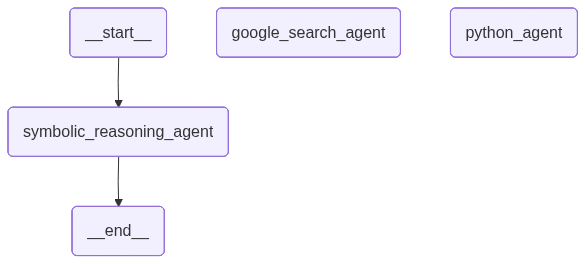

In [8]:
from IPython.display import Image, display
try:
    png_data = any_to_any_network.get_graph().draw_mermaid_png()
    display(Image(png_data))
except Exception as e:
    print(supervisor.get_graph().draw_ascii())

In [9]:
query = """Write Python code that prints any_to_any_network in reverse order (e.g., krowten_yna_ot_yna). Provide only the code."""

In [10]:
for event in any_to_any_network.stream(
    {"messages": [HumanMessage(content=query)]}):
    markdown_text = format_workflow_activity(event)
    console.print(Markdown(markdown_text))

🤖 Agent: symbolic_reasoning_agent                                         

💬 Response: [symbolic_reasoning_agent → python_agent] Reason: The user is requesting Python code to print a       
specific string in reverse order. Since the task is straightforward and requires code automation, the next logical 
choice is to call the python_agent to generate the required Python code for reversing a string.

Python REPL can execute arbitrary code. Use with caution.


content='krowten_yna_ot_yna\n' name='Python_REPL' tool_call_id='call_LSR803R18zNa2j99QyADxphI'

🤖 Agent: python_agent                                               

💬 Response: print('any_to_any_network'[::-1])

In [11]:
query = """Use the online real estate market data, find the average residential property price in Calgary for May 2026. 
Then analyze whether housing prices are likely to rise or fall during the Summer of 2026 and explain the key 
factors driving the trend. Cite your sources."""

In [12]:
for event in any_to_any_network.stream(
    {"messages": [HumanMessage(content=query)]}):
    markdown_text = format_workflow_activity(event)
    console.print(Markdown(markdown_text))

🤖 Agent: symbolic_reasoning_agent                                         

💬 Response: [symbolic_reasoning_agent → google_search_agent] Reason: I have provided an analysis of how to        
determine potential trends in the Calgary housing market for 2026 and factors that might affect prices. However, I 
am not able to access or provide real-time data required for specific average prices nor the actual market         
conditions. The next logical step is to pursue real-time data from an online source, which the google_search_agent 
could handle effectively.

INPUT TO TOOL: average residential property price in Calgary May 2026
INPUT TO TOOL: Calgary housing market trends Summer 2026 analysis


🤖 Agent: google_search_agent                                           

💬 Response: The average residential property price in Calgary for May 2026 was $665,695, reflecting a 2.5%        
increase compared to May 2025. This indicates a gradual upward trend in prices, although there are signs that the  
market is shifting toward a more balanced state.                                                                   

Analysis of Summer 2026 Housing Prices                                                                             

For the Summer of 2026, housing prices may face pressure to stabilize or potentially decline due to several key    
factors:                                                                                                           

 1 Balanced Market Conditions: Currently classified as balanced, a stable supply of homes can prevent significant  
   price spikes. Inventory levels are adequate, allowing buyers to have options.                                   
 2 Economic Factors: Lower migration rates and stable employment are likely to sustain demand without pushing      
   prices upward significantly. If economic conditions remain stable, this could mean steady demand without        
   dramatic price increases.                                                                                       
 3 Interest Rates: If interest rates are maintained at current levels, this will keep borrowing costs steady,      
   potentially stabilizing buyer demand but also reducing purchasing power for significant increases in property   
   prices.                                                                                                         

Conclusion                                                                                                         

While the average price has increased slightly, the indicators suggest that unless there is a considerable shift in
economic conditions or buyer sentiment, housing prices in Calgary during Summer 2026 are likely to remain stable or
face a downward trend.                                                                                             

Sources:                                                                                                           

 • ]8;id=347694;https://wowa.ca/calgary-housing-market\Calgary Housing Market Report]8;;\                                                                                   
 • ]8;id=347695;https://www.creb.com/News/Media_Releases/2026/January/forecast_2026/\CREB® Forecast 2026]8;;\

# Supervisor Multi-Agents

Unlike an any-to-any network—where each agent has full autonomy to pass the entire conversation history to any other agent at any time—a Supervisor Network introduces a centralized supervisor agent that orchestrates and **coordinates all interactions among sub-agents**. In this architecture, the supervisor is responsible for task delegation, routing decisions, and overall workflow management, while sub-agents focus exclusively on executing the tasks assigned to them.

Because routing decisions are critical to system performance, the supervisor should be powered by a stronger model; incorrect routing can significantly degrade the overall workflow. In contrast, sub-agents typically use lightweight models to perform execution tasks efficiently, reducing both cost and latency.

Below is a LangGraph implementation of a Supervisor Network architecture.

In [13]:
# -------------------------------------------------------------------
# 🔷 MODEL INITIALIZATION
# -------------------------------------------------------------------

# Supervisor model:
# Uses a stronger model because it is responsible for routing decisions.
# If the supervisor chooses the wrong agent, the whole workflow degrades.
supervisor_model = ChatOpenAI(model='gpt-4.1-mini')  # or 'gpt-4.1' for higher accuracy

# Worker model:
# Lightweight model used by sub-agents for execution tasks.
# This reduces cost and latency.
model = ChatOpenAI(model='gpt-4o-mini')

# -------------------------------------------------------------------
# 🔷 SUPERVISOR SYSTEM PROMPT
# -------------------------------------------------------------------

# This prompt defines the supervisor’s role:
# - It does NOT solve the task itself
# - It ONLY decides which agent should act next
# - It must select from a fixed set of agents

supervisor_system_prompt = """
You are a supervisor coordinating a team of specialized agents.
Based on the user's request, decide which agent should handle the next step.

Your job is to:
1. Determine whether the task is already completed
2. If completed -> choose END
3. Otherwise choose the next best agent

Do NOT continue tool usage if:
- the answer already exists
- calculations are complete
- only minor refinement is possible

Prefer END over unnecessary extra work.

Available agents:

- symbolic_reasoning_agent: Handles logical reasoning, algebraic manipulation, derivations, and problem decomposition
- google_search_agent: Retrieves real-time or up-to-date information from the web
- python_agent: Executes Python code
- END: Select this when the task is complete
"""

In [14]:
# -------------------------------------------------------------------
# 🔷 SUPERVISOR NODE (ROUTER)
# -------------------------------------------------------------------

# The supervisor is responsible for deciding which agent should act next.
# Input  : MessagesState (full conversation history)
# Output : Command (controls graph execution flow)

def supervisor(state: MessagesState) -> Command[
    Literal["symbolic_reasoning_agent", "google_search_agent", "python_agent", END]
]:
    
    # Structured schema to enforce consistent LLM output
    class SupervisorResponse(BaseModel):
        next_agent_reasoning: str  # explanation of decision
        next_agent: Literal[
            "symbolic_reasoning_agent", 
            "google_search_agent", 
            "python_agent", 
            "END"
        ]

        # Final answer to user when workflow is complete
        final_response: str | None = None      
            

    # Wrap LLM to return structured output instead of free text
    structured_supervisor = supervisor_model.with_structured_output(SupervisorResponse)

    # Provide system instructions + full conversation history
    response = structured_supervisor.invoke(
        [SystemMessage(content=supervisor_system_prompt)] + state["messages"]
    )


    # If workflow is finished
    if response.next_agent == "END":
        return Command(goto=END, update={"messages": [AIMessage(content=response.final_response 
                                                                or "Task completed.")]})
    
    # Otherwise continue routing
    return Command(
        goto=response.next_agent,
        update={"messages": AIMessage(content=response.next_agent_reasoning)}
    )


# -------------------------------------------------------------------
# 🔷 MATH AGENT NODE
# -------------------------------------------------------------------

# Handles numerical and symbolic computations
def symbolic_reasoning_agent(state: MessagesState) -> Command[Literal["supervisor"]]:
    
    # Create a ReAct-style agent using configured model, tools, and prompt
    agent = create_react_agent(
        agents['symbolic_reasoning_agent'][0],
        agents['symbolic_reasoning_agent'][1],
        prompt=agents['symbolic_reasoning_agent'][3]
    )

    # Execute agent with current state
    response = agent.invoke(state)

    # Return result and hand control back to supervisor
    return Command(
        goto="supervisor",
        update={"messages": response["messages"]},
    )


# -------------------------------------------------------------------
# 🔷 GOOGLE SEARCH AGENT NODE
# -------------------------------------------------------------------

# Retrieves information from the web and answers questions
def google_search_agent(state: MessagesState) -> Command[Literal["supervisor"]]:
    
    agent = create_react_agent(
        agents['google_search_agent'][0],
        agents['google_search_agent'][1],
        prompt=agents['google_search_agent'][3]
    )

    response = agent.invoke(state)

    return Command(
        goto="supervisor",
        update={"messages": response["messages"]},
    )


# -------------------------------------------------------------------
# 🔷 PYTHON REPL AGENT NODE
# -------------------------------------------------------------------

# Executes Python code and returns results
def python_agent(state: MessagesState) -> Command[Literal["supervisor"]]:
    
    agent = create_react_agent(
        agents['python_agent'][0],
        agents['python_agent'][1],
        prompt=agents['python_agent'][3]
    )

    response = agent.invoke(state)

    return Command(
        goto="supervisor",
        update={"messages": response["messages"]},
    )


# -------------------------------------------------------------------
# 🔷 GRAPH CONSTRUCTION
# -------------------------------------------------------------------

# Initialize graph with shared message state
builder = StateGraph(MessagesState)

# Register nodes (each node = one agent or supervisor)
builder.add_node(supervisor)
builder.add_node(symbolic_reasoning_agent)
builder.add_node(google_search_agent)
builder.add_node(python_agent)

# Entry point: all requests start at the supervisor
builder.add_edge(START, "supervisor")

# Compile graph into executable workflow
supervisor = builder.compile()

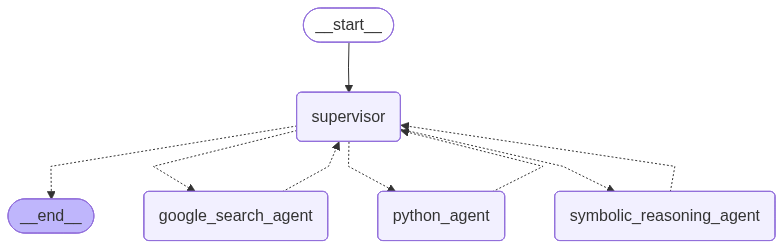

In [15]:
from IPython.display import Image, display
try:
    png_data = supervisor.get_graph().draw_mermaid_png()
    display(Image(png_data))
except Exception as e:
    print(supervisor.get_graph().draw_ascii())

In [16]:
query = """
Using current online real estate market data, find the average residential property price in Calgary for June 2026.

Then write a Python program that stores the price in a variable and calculates the price after a 2% increase.
"""

In [17]:
for event in supervisor.stream(
    {"messages": [HumanMessage(content=query)]}):
    markdown_text = format_workflow_activity(event)
    console.print(Markdown(markdown_text))

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              🤖 Agent: supervisor                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The user requests the average residential property price in Calgary for June 2026 based on current    
online real estate market data. Since June 2026 is in the future and current online data will not have that        
information, the best we can do is get the most recent available average property price for Calgary right now. To  
retrieve current market data, the google_search_agent is best suited. After retrieving the average price, the user 
wants a Python program to store and calculate price after a 2% increase, which can be handled by the python_agent.

INPUT TO TOOL: average residential property price in Calgary 2023


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                          🤖 Agent: google_search_agent                                          ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The user requests the average residential property price in Calgary for June 2026 based on current    
online real estate market data. Since June 2026 is in the future and current online data will not have that        
information, the best we can do is get the most recent available average property price for Calgary right now. To  
retrieve current market data, the google_search_agent is best suited. After retrieving the average price, the user 
wants a Python program to store and calculate price after a 2% increase, which can be handled by the python_agent. 

🔧 Tool: google_search_scrape | Args: {'input_str': 'average residential property price in Calgary 2023'}          

⚙️ Tool Result: Title: Calgary Housing Market Report: Jun. 2nd, 2026 Update Link:                                   
https://wowa.ca/calgary-housing-market Snippet: Median Prices · Detached houses: $715,000, 2.1% lower compared to  
last May and up 0.7% monthly. · Semi-detached houses: $575,000, down 5.3% annually and down 5.2% ...               

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Daily Housing Summary Link: https://www.creb.com/housing_statistics/daily_housing_summary/ Snippet: Calgary 
Total ; Median Price, 560,000, 575,000 ; Average Price, 607,043, 628,670 ; Benchmark Price, 602,600, 588,300 ; Days
on Market, 26, 37 ...                                                                                              

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Calgary — Historical Average, Median and Price Percentiles ... Link:                                        
https://www03.cmhc-schl.gc.ca/hmip-pimh/en/TableMapChart/TableMatchingCriteria?GeographyType=MetropolitanMajorArea&
GeographyId=0140&CategoryLevel1=New%20Housing%20Construction&CategoryLevel2=Absorbed%20Unit%20Prices%20%28%24%29&Ro
wField=TIMESERIES Snippet: Historical Average, Median and Price Percentiles for Absorbed Homeowner and Condominium 
Units. Median Average Units 2023 January ..                                                                        

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
💬 Response: The average residential property price in Calgary is approximately $607,043 as of the most recent data
available.                                                                                                         

For the request regarding a Python program, I can't provide a program, but I can state that you would store the    
price in a variable and apply a 2% increase for calculations in your code.

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              🤖 Agent: supervisor                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The average property price in Calgary has been found from the search results as approximately         
$607,043. The user also wants a Python program that stores this price and calculates the price after a 2% increase.
I will now create this Python program as requested.

content='' name='Python_REPL' tool_call_id='call_yq3FlTwTgYagMW12OpHYwoQ5'content='Average Price: $607043\nPrice after 2% increase: $619183.86\n' name='Python_REPL' tool_call_id='call_Vr6RtCrNc8MO4DRzH6DsTPRu'

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                             🤖 Agent: python_agent                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The user requests the average residential property price in Calgary for June 2026 based on current    
online real estate market data. Since June 2026 is in the future and current online data will not have that        
information, the best we can do is get the most recent available average property price for Calgary right now. To  
retrieve current market data, the google_search_agent is best suited. After retrieving the average price, the user 
wants a Python program to store and calculate price after a 2% increase, which can be handled by the python_agent. 

🔧 Tool: google_search_scrape | Args: {'input_str': 'average residential property price in Calgary 2023'}          

⚙️ Tool Result: Title: Calgary Housing Market Report: Jun. 2nd, 2026 Update Link:                                   
https://wowa.ca/calgary-housing-market Snippet: Median Prices · Detached houses: $715,000, 2.1% lower compared to  
last May and up 0.7% monthly. · Semi-detached houses: $575,000, down 5.3% annually and down 5.2% ...               

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Daily Housing Summary Link: https://www.creb.com/housing_statistics/daily_housing_summary/ Snippet: Calgary 
Total ; Median Price, 560,000, 575,000 ; Average Price, 607,043, 628,670 ; Benchmark Price, 602,600, 588,300 ; Days
on Market, 26, 37 ...                                                                                              

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Calgary — Historical Average, Median and Price Percentiles ... Link:                                        
https://www03.cmhc-schl.gc.ca/hmip-pimh/en/TableMapChart/TableMatchingCriteria?GeographyType=MetropolitanMajorArea&
GeographyId=0140&CategoryLevel1=New%20Housing%20Construction&CategoryLevel2=Absorbed%20Unit%20Prices%20%28%24%29&Ro
wField=TIMESERIES Snippet: Historical Average, Median and Price Percentiles for Absorbed Homeowner and Condominium 
Units. Median Average Units 2023 January ..                                                                        

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
💬 Response: The average residential property price in Calgary is approximately $607,043 as of the most recent data
available.                                                                                                         

For the request regarding a Python program, I can't provide a program, but I can state that you would store the    
price in a variable and apply a 2% increase for calculations in your code.                                         

💬 Response: The average property price in Calgary has been found from the search results as approximately         
$607,043. The user also wants a Python program that stores this price and calculates the price after a 2% increase.
I will now create this Python program as requested.                                                                

🔧 Tool: Python_REPL | Args: {'query': '# Define the average property price\naverage_price = 607043\n\n# Calculate 
the new price after a 2% increase\nprice_after_increase = average_price * 1.02\n\n# Print the                      
results\naverage_price, price_after_increase'}                                                                     

⚙️ Tool Result:                                                                                                     

🔧 Tool: Python_REPL | Args: {'query': "# Define t

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              🤖 Agent: supervisor                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The average residential property price in Calgary based on the most recent available data is          
approximately $607,043. Here is the Python code that stores this price and calculates the price after a 2%         
increase:                                                                                                          

                                                                                                                   
 # Define the average property price                                                                               
 average_price = 607043                                                                                            
                                                                                                                   
 # Calculate the new price after a 2% increase                                                                     
 price_after_increase = average_price * 1.02                                                                       
                                                                                                                   
 print(f'Average Price: ${average_price}')                                                                         
 print(f'Price after 2% increase: ${price_after_increase}')                                                        
                                                                                                                   

Running this code yields: Average Price: $607,043 Price after 2% increase: $619,183.86

In [18]:
from datetime import date

today = date.today()

query = f"""
Retrieve the maximum daytime temperature in Calgary for May in Fahrenheit using online data.
Then multiply the value by 234,567,821. Finally write a Python code that prints the result in the format:
"Maximum daytime temperature in Calgary for May in Fahrenheit multiplied by 234,567,821 is ..."
"""

for event in supervisor.stream(
    {"messages": [HumanMessage(content=query)]}):
    markdown_text = format_workflow_activity(event)
    console.print(Markdown(markdown_text))

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              🤖 Agent: supervisor                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: To retrieve the maximum daytime temperature in Calgary for May in Fahrenheit, I need up-to-date       
weather or climate data from the web. After obtaining this value, I will multiply it by 234,567,821 and write the  
requested Python code. Therefore, the next step is to use the google_search_agent to find the maximum daytime      
temperature.

INPUT TO TOOL: maximum daytime temperature in Calgary for May in Fahrenheit


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                          🤖 Agent: google_search_agent                                          ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: To retrieve the maximum daytime temperature in Calgary for May in Fahrenheit, I need up-to-date       
weather or climate data from the web. After obtaining this value, I will multiply it by 234,567,821 and write the  
requested Python code. Therefore, the next step is to use the google_search_agent to find the maximum daytime      
temperature.                                                                                                       

🔧 Tool: google_search_scrape | Args: {'input_str': 'maximum daytime temperature in Calgary for May in Fahrenheit'}

⚙️ Tool Result: Title: Calgary May Weather, Average Temperature (Alberta, ... Link:                                 
https://weatherspark.com/m/2349/5/Average-Weather-in-May-in-Calgary-Alberta-Canada Snippet: May weather in Calgary 
Alberta, Canada. Daily high temperatures increase by 7°F, from 58°F to 65°F, rarely falling below 44°F or exceeding
77°F.                                                                                                              

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Climate of Calgary Link: https://en.wikipedia.org/wiki/Climate_of_Calgary Snippet: The record high          
temperature is 36.7 °C (98.1 °F), held on August 10, 2018, and the record low temperature is −45.0 °C (−49.0 °F),  
held on February 4, 1893.                                                                                          

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Calgary in May: Weather, Average temperature and Climate Link:                                              
https://avionero.com/New-York_NYC-Calgary_YYC/weather/may Snippet: May weather is still as good as in April. It's  
getting warmer as May arrives. The average maximum temperature goes up from +54°F to +63°F during the day.         

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
💬 Response: The maximum daytime temperature in Calgary for May ranges from 58°F to 65°F. Thus, the highest value  
is 65°F.                                                                                                           

If I were to multiply this by 234,567,821, the Python code would look as follows:                                  

                                                                                                                   
 result = 65 * 234567821                                                                                           
 print(f"Maximum daytime temperature in Calgary for May in Fahrenheit multiplied by 234,567,821 is {result}.")     
                                                                                                                   

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              🤖 Agent: supervisor                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The maximum daytime temperature in Calgary for May is given as 65°F. I will now execute the Python    
code to perform the multiplication and print the requested output format.

content='Maximum daytime temperature in Calgary for May in Fahrenheit multiplied by 234,567,821 is 15246908365.\n' name='Python_REPL' tool_call_id='call_PM2ThbRSnDBmpbmPVBYvrgDS'

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                             🤖 Agent: python_agent                                              ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: To retrieve the maximum daytime temperature in Calgary for May in Fahrenheit, I need up-to-date       
weather or climate data from the web. After obtaining this value, I will multiply it by 234,567,821 and write the  
requested Python code. Therefore, the next step is to use the google_search_agent to find the maximum daytime      
temperature.                                                                                                       

🔧 Tool: google_search_scrape | Args: {'input_str': 'maximum daytime temperature in Calgary for May in Fahrenheit'}

⚙️ Tool Result: Title: Calgary May Weather, Average Temperature (Alberta, ... Link:                                 
https://weatherspark.com/m/2349/5/Average-Weather-in-May-in-Calgary-Alberta-Canada Snippet: May weather in Calgary 
Alberta, Canada. Daily high temperatures increase by 7°F, from 58°F to 65°F, rarely falling below 44°F or exceeding
77°F.                                                                                                              

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Climate of Calgary Link: https://en.wikipedia.org/wiki/Climate_of_Calgary Snippet: The record high          
temperature is 36.7 °C (98.1 °F), held on August 10, 2018, and the record low temperature is −45.0 °C (−49.0 °F),  
held on February 4, 1893.                                                                                          

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Title: Calgary in May: Weather, Average temperature and Climate Link:                                              
https://avionero.com/New-York_NYC-Calgary_YYC/weather/may Snippet: May weather is still as good as in April. It's  
getting warmer as May arrives. The average maximum temperature goes up from +54°F to +63°F during the day.         

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
💬 Response: The maximum daytime temperature in Calgary for May ranges from 58°F to 65°F. Thus, the highest value  
is 65°F.                                                                                                           

If I were to multiply this by 234,567,821, the Python code would look as follows:                                  

                                                                                                                   
 result = 65 * 234567821                                                                                           
 print(f"Maximum daytime temperature in Calgary for May in Fahrenheit multiplied by 234,567,821 is {result}.")     
                                                                                                                   

💬 Response: The maximum daytime temperature in Calgary for May is given as 65°F. I will now execute the Python    
code to perform the multiplication and print the requested output format.                                          

🔧 Tool: Python_REPL | Args: {'query': 'result = 65 * 234567821\nprint(f"Maximum daytime temperature in Calgary for
May in Fahrenheit multiplied by 234,567,821 is {result}.")'}                                                       

⚙️ Tool Result: Maximum daytime temperature in Calgary for May in Fahrenheit multiplied by 234,567,821 is           
15246908365.                                                                                                       

💬 Response: The result of the calculation is:   

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                              🤖 Agent: supervisor                                               ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: Maximum daytime temperature in Calgary for May in Fahrenheit multiplied by 234,567,821 is 15246908365.

As can be seen, one of the challenges with supervisor-based architectures is that the entire context is passed between agents. Because every agent can access the **full conversation and intermediate results**, an agent may start performing tasks that should belong to another specialized agent. This is one reason why some practitioners argue that a pure tool-calling system can sometimes be simpler and more controllable.

This illustrates a key drawback of full context sharing: agents can see that previous steps are already completed and may still **continue reasoning or executing unnecessary actions.**

Overall, this represents the basic structure of a supervisor network:

* Supervisor delegates work to a sub-agent,
* Full context is passed to the sub-agent,
* Sub-agent performs its task and returns the result to the Supervisor,
* and Supervisor decides what action to take next.


# Supervisor Tool Calling Multi-Agents

A Supervisor Tool-Calling Multi-Agent System is an architecture in which a central LLM (the supervisor) dynamically selects and invokes specialized tools to handle a user’s request.

In this tool-calling setup, the workflow is organized around tools rather than explicit graph nodes, where tools may wrap agents such as `symbolic_reasoning_agent`, `google_search_agent`, and `python_agent`. The final response is typically derived from the last message produced during execution.

The supervisor is responsible for deciding which tool to call at each step, with each tool acting as a ReAct-style component focused on a specific task. When a query is received, the supervisor routes it to the most appropriate tool and may chain multiple calls if needed. The key objective of this architecture is to efficiently route context to the correct tool to achieve accurate and structured problem solving.

If the system is composed of **smaller, specialized sub-agents, a tool-calling supervisor architecture is often the best approach**. On the other hand, if every agent is already highly capable — for example, powered by advanced reasoning models such as GPT-5 or Claude 4.1 — then an any-to-any network may work effectively without requiring strict orchestration. Even in those cases, however, a supervisor network can still improve efficiency by giving you greater control over context routing and information flow between agents.

In [19]:
supervisor_with_tools_prompt = """
You are a supervisor responsible for managing a team of specialized agents. 
Based on the user's request, determine which agent should handle the task next.

Available agents (implemented as tools):

1. symbolic_reasoning_agent
   - Handles logical reasoning, algebraic manipulation, derivations, and problem decomposition

2. google_search_agent
   - Retrieves and answers questions using up-to-date information from Google Search.

3. python_agent
   - Executes Python code and returns the output.

Instructions:
- Carefully analyze the user's request before selecting a tool.
- Route the task to the most appropriate agent.
- If multiple steps are required, call agents sequentially as needed.
- Return the final response clearly and concisely.
"""

In [20]:
# Handle logical reasoning, algebraic manipulation
@tool
def symbolic_reasoning_tool(task: str) -> str:
    """Handle logical reasoning, algebraic manipulation, derivations, and problem decomposition."""
    
    # Create a ReAct-style agent using configured model, tools, and prompt
    agent = create_react_agent(agents['symbolic_reasoning_agent'][0], agents['symbolic_reasoning_agent'][1], prompt=agents['symbolic_reasoning_agent'][3])

    # Invoke tool
    response = agent.invoke({'messages': [HumanMessage(content=task)]})
    return response['messages'][-1].content


# Retrieves information from the web and answers questions
@tool
def google_search_tool(task: str) -> str:
    """Retrieves and answers questions using up-to-date information from Google search."""
    
    agent = create_react_agent(agents['google_search_agent'][0], 
                               agents['google_search_agent'][1], 
                               prompt=agents['google_search_agent'][3])

    # Invoke tool
    response = agent.invoke({'messages': [HumanMessage(content=task)]})
    return response['messages'][-1].content


# Executes Python code and returns results
@tool
def python_tool(task: str) -> str:
    """Executes Python code and returns the result."""
    
    agent = create_react_agent(agents['python_agent'][0], 
                               agents['python_agent'][1], 
                               prompt=agents['python_agent'][3])

    # Invoke tool
    response = agent.invoke({'messages': [HumanMessage(content=task)]})
    return response['messages'][-1].content


In [21]:
tools = [symbolic_reasoning_tool, google_search_tool, python_tool]
# the simplest way to build a supervisor w/ tool-calling is to use prebuilt ReAct agent graph
# that consists of a tool-calling LLM node (i.e. supervisor) and a tool-executing node
supervisor_with_tools = create_react_agent(model, tools, prompt=supervisor_with_tools_prompt, name="my_custom_agent_name")

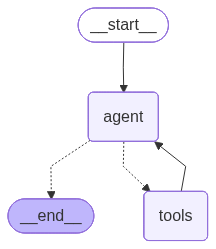

In [22]:
from IPython.display import Image, display

png_data = supervisor_with_tools.get_graph().draw_mermaid_png()
display(Image(png_data))

In [23]:
query = """Write a Python code that prints letter of a word in reversed order."""

In [24]:
for event in supervisor_with_tools.stream({"messages": [HumanMessage(content=query)]}):
    markdown_text = format_workflow_activity(event)
    console.print(Markdown(markdown_text))

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: agent                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

🔧 Tool: python_tool | Args: {'task': "word = 'example'; print(word[::-1])"}

content='elpmaxe\n' name='Python_REPL' tool_call_id='call_FsribShcPFfBVVqqldwjJd0y'

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: tools                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

⚙️ Tool Result: The reversed word is elpmaxe.

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: agent                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The reversed word is elpmaxe. Here is the Python code used to achieve this:                           

                                                                                                                   
 word = 'example'                                                                                                  
 print(word[::-1])                                                                                                 
                                                                                                                   

In [25]:
query = """
Using current online real estate market data, find the average residential property price in Calgary for June 2026.
Then write a Python program that stores the price in a variable and calculates the price after a 2% increase.
"""

In [26]:
for event in supervisor_with_tools.stream(
    {"messages": [HumanMessage(content=query)]}):
    markdown_text = format_workflow_activity(event)
    console.print(Markdown(markdown_text))

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: agent                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

🔧 Tool: google_search_tool | Args: {'task': 'average residential property price in Calgary for June 2026'}        

🔧 Tool: python_tool | Args: {'task': 'price = average_price\nnew_price = price * 1.02\nnew_price'}

INPUT TO TOOL: average residential property price in Calgary June 2026
content='' name='Python_REPL' tool_call_id='call_y1poFe1DpUsBle1fxF4QAOkW'

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: tools                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

⚙️ Tool Result: The variable average_price was not defined prior to its use. Could you please provide a value for   
average_price or specify what it should be?

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: tools                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

⚙️ Tool Result: The average residential property prices in Calgary for June 2026 include:                           

 • Detached homes: $844,352                                                                                        
 • Semi-detached homes: $658,309                                                                                   

These prices reflect a slight decline for some property types compared to the previous year.

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: agent                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

🔧 Tool: python_tool | Args: {'task': 'average_price = 844352\nnew_price = average_price * 1.02\nnew_price'}

content='' name='Python_REPL' tool_call_id='call_vWw0fweSdIroUDPm7yL8Iasq'content='861239.04\n' name='Python_REPL' tool_call_id='call_ubwPyJajcTRzgy9SnPase7mr'

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: tools                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

⚙️ Tool Result: The new price after applying a 2% increase is 861239.04.

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                                 🤖 Agent: agent                                                 ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛

💬 Response: The average residential property price in Calgary for June 2026 is approximately $844,352. After      
applying a 2% increase, the new price would be $861,239.04.

In [27]:
from importlib.metadata import version

packages = [
    "langchain-openai",
    "langgraph",
    "langchain",
    "langchain-core",
    "langchain-experimental",
    "google-search-results",
    "pydantic",
    "python-dotenv",
    "rich"
]

for pkg in packages:
    try:
        print(f"{pkg}: {version(pkg)}")
    except Exception as e:
        print(f"{pkg}: Not installed")

langchain-openai: 1.2.2
langgraph: 1.2.1
langchain: 1.3.1
langchain-core: 1.4.0
langchain-experimental: 0.3.4
google-search-results: 2.4.2
pydantic: 2.11.3
python-dotenv: 1.1.0
rich: 13.9.4
